### **This tutorial demonstrates how to train a Logistic Regression model using Scikit learn on the Titanic Dataset from Kaggle**

**We will cover:**

**• data preprocessing**

**• feature encoding**

**• handling missing values**

**• model training**

**• model evaluation**

## **Introduction to Logistic Regression**

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. Despite its name, it is a classification model rather than a regression model. The goal of logistic regression is to estimate the probability that a given input belongs to a particular class.

In logistic regression, the model first computes a linear combination of the input features:

Z = W*X + B

where W are the learned weights

B is the bias term

This linear output is then passed through the sigmoid (logistic) function, which converts the value into a probability between 0 and 1:

the predicted output equals to σ(z):
1/(1 + 𝑒^ −𝑧)
	​
The sigmoid function ensures that the model output can be interpreted as a probability of belonging to the positive class.

During training, logistic regression learns the model parameters by minimizing the log loss (binary cross-entropy loss):


Optimization is typically performed using gradient-based methods such as LBFGS or stochastic gradient descent, which iteratively adjust the model weights to minimize the loss.

Once trained, the model predicts a class by applying a decision threshold (commonly 0.5):

probability ≥ 0.5 → class 1

probability < 0.5 → class 0

Logistic regression is widely used because it is:

* interpretable (model coefficients indicate feature influence)

* computationally efficient

* a strong baseline model for classification tasks

In this tutorial, we will use scikit-learn's LogisticRegression implementation to train a classifier on the Titanic dataset, demonstrating the complete workflow from data preprocessing to model evaluation.

## **LOADING DATA**

In [237]:
# For the logistic regression tutorial, we going to use the popular Titanic dataset from Kaggle
# The train and test sets of the Titanic dataset were downloaded from Kaggle.

In [238]:
import pandas as pd

In [324]:
train = pd.read_csv("train.csv") # download train and test csv from the following link
test = pd.read_csv("test.csv")   # https://www.kaggle.com/competitions/titanic/data
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [240]:
y = train["Survived"] # separated the target column from test dataset, necessary for model training and evaluation
train = train.drop(columns = ["Survived", "PassengerId", "Name","Ticket"])  # Passenger Id is basically useless feature, adds unnecessary noise

PID_test = test["PassengerId"] #saved the test passnger Id's as we will need it later while submitting test predictions to kaggle
test = test.drop(columns = ["PassengerId", "Name","Ticket"])

## **Data Analysis, Encoding and Imputing**


In [241]:
# We see 3 columns have missing values, we need to fill them with suitable data (also called  Imputing), like mode, mean or using more complex methods like Iterative Imputer
# As we see there are many object (text) columns, some columns also have missing (nan) values
# Machine learning models demand fully numerical data as they learn statistical relations and patterns from numbers
# So we need to properly pre process the data before feeding it into the model
# Also we need to apply same transforms on both test and train sets so the model is tested on same data format as it was trained on

In [242]:
train.info() #we see 5 columns are of dtype object, so we need to encode them, Encoding: convert non numerical values/columns into numerical form

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Cabin     204 non-null    object 
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 55.8+ KB


In [243]:
train.isna().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [244]:
total_null_cabin = train["Cabin"].isna().sum() #total null values in column cabin
total_entries_cabin = len(train["Cabin"])
cabin_missing_ratio = total_null_cabin/total_entries_cabin
print(f"Percent of missing values in column Cabin: {100*cabin_missing_ratio:.2f}%") #we see the column Cabin is missing >77% of values, so it is basically useless for us so we will drop it from both train and test sets

Percent of missing values in column Cabin: 77.10%


In [245]:
train = train.drop(columns = ["Cabin"])
test = test.drop(columns =["Cabin"])
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,3,female,NaN,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [246]:
train["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [247]:
train.isna().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
# now only columns Age and Embarked have missing values, since Embarked has only 2 missing values, we'll fill it quickly with the mode(most frequent value) of the column

In [248]:
test.isna().sum()

,0
Pclass,0
Sex,0
Age,86
SibSp,0
Parch,0
Fare,1
Embarked,0


In [249]:
train["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [250]:
mode_embarked = train["Embarked"].mode()
mode_embarked

,Embarked
0,S


In [251]:
train["Embarked"] = train["Embarked"].fillna("S")

In [252]:
# Now we will impute missing values in the column Age, since it is numerical and has many missing values (177), we will use sklearn's iterative imputer
# Iterative imputer basically works by using models like Random Forest or KNN and training it on columns other than the one that needs imputation
# It makes the to be imputed column as target column and the data points who have the column value nan as the test set, the rest as train set
# then it predicts the missing values after training from the rest of the data and fills in the nan values

In [253]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [254]:
imputer = IterativeImputer(max_iter = 20, random_state = 42)
train["Age"] = imputer.fit_transform(train[["Age"]]) # using fit function so that it learns from train set
test["Age"] = imputer.transform(test[["Age"]]) # not using fit function so that it uses info learned from train set, as same pipeline is used during real time inference cases

In [255]:
# test set also has a missing value in Fare column, we'll use mean to fill it since its numerical unlike Embarked where we cant use mean
test["Fare"] = test["Fare"].fillna(test["Fare"].mean())

In [256]:
train.isna().sum() # now train set has no missing value columns

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [257]:
test.isna().sum() # test set also has no missing values, so imputation is completed, now we need to do encoding

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [258]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [259]:
train.nunique() # now time for encoding, there are 2 object cols: sex, embarked

,0
Pclass,3
Sex,2
Age,89
SibSp,7
Parch,7
Fare,248
Embarked,3


In [260]:
# we can encode values that is convert string to numbers using two techniques: One hot encoding which generates n number of new boolean columns,
# where n equals to number of unique values in the original column. The new columns are in binary 0/1 form
# another way is label/ordinal encoding which preserves order in data and assigns a unique number to each new value, like 1 for A, 2 for B and so on

In [261]:
# since Embarked column has only three unique values which also dont have any order/rank among them, we'll use on hot encoding for it
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.000000,1,0,7.2500,S
1,1,female,38.000000,1,0,71.2833,C
2,3,female,26.000000,0,0,7.9250,S
3,1,female,35.000000,1,0,53.1000,S
4,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000,S
887,1,female,19.000000,0,0,30.0000,S
888,3,female,29.699118,1,2,23.4500,S
889,1,male,26.000000,0,0,30.0000,C


In [262]:
train = pd.get_dummies(train, columns = ["Embarked"], prefix = "Embarked", dtype = int)
test = pd.get_dummies(test, columns = ["Embarked"], prefix = "Embarked", dtype = int)
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,male,22.000000,1,0,7.2500,0,0,1
1,1,female,38.000000,1,0,71.2833,1,0,0
2,3,female,26.000000,0,0,7.9250,0,0,1
3,1,female,35.000000,1,0,53.1000,0,0,1
4,3,male,35.000000,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000,0,0,1
887,1,female,19.000000,0,0,30.0000,0,0,1
888,3,female,29.699118,1,2,23.4500,0,0,1
889,1,male,26.000000,0,0,30.0000,1,0,0


In [263]:
# now time to label encode Sex we'll use sklearn's label encoder

In [264]:
from sklearn.preprocessing import LabelEncoder

encoder_sex = LabelEncoder()

train["Sex"] = encoder_sex.fit_transform(train["Sex"])
test["Sex"] = encoder_sex.transform(test["Sex"])

train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,1,22.000000,1,0,7.2500,0,0,1
1,1,0,38.000000,1,0,71.2833,1,0,0
2,3,0,26.000000,0,0,7.9250,0,0,1
3,1,0,35.000000,1,0,53.1000,0,0,1
4,3,1,35.000000,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,0,0,1
887,1,0,19.000000,0,0,30.0000,0,0,1
888,3,0,29.699118,1,2,23.4500,0,0,1
889,1,1,26.000000,0,0,30.0000,1,0,0


In [265]:
# final analysis

In [266]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Sex         891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Embarked_C  891 non-null    int64  
 7   Embarked_Q  891 non-null    int64  
 8   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


In [267]:
train.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked_C,0
Embarked_Q,0
Embarked_S,0


In [268]:
train.describe()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208,0.188552,0.086420,0.725028
std,0.836071,0.477990,13.002015,1.102743,0.806057,49.693429,0.391372,0.281141,0.446751
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000
50%,3.000000,1.000000,29.699118,0.000000,0.000000,14.454200,0.000000,0.000000,1.000000
75%,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,0.000000,0.000000,1.000000
max,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000


In [269]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Sex         418 non-null    int64  
 2   Age         418 non-null    float64
 3   SibSp       418 non-null    int64  
 4   Parch       418 non-null    int64  
 5   Fare        418 non-null    float64
 6   Embarked_C  418 non-null    int64  
 7   Embarked_Q  418 non-null    int64  
 8   Embarked_S  418 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 29.5 KB


In [270]:
test.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked_C,0
Embarked_Q,0
Embarked_S,0


In [271]:
#  so now both train and test set are imputed and encoded uniformly in same manner

## **Exploratory Data Analysis**

In [272]:
# Now we will analyze the data and understand the patterns between the features

In [273]:
data = train
data["Survived"] = y
data #added the Survived column to train data by making a new variable "data", to visualize it without interfering between train set

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
0,3,1,22.000000,1,0,7.2500,0,0,1,0
1,1,0,38.000000,1,0,71.2833,1,0,0,1
2,3,0,26.000000,0,0,7.9250,0,0,1,1
3,1,0,35.000000,1,0,53.1000,0,0,1,1
4,3,1,35.000000,0,0,8.0500,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,0,0,1,0
887,1,0,19.000000,0,0,30.0000,0,0,1,1
888,3,0,29.699118,1,2,23.4500,0,0,1,0
889,1,1,26.000000,0,0,30.0000,1,0,0,1


In [274]:
encoder_sex.classes_ # maps to array [0,1], so female means 0 and male means 1

array(['female', 'male'], dtype=object)

In [275]:
data.groupby("Survived")["Sex"].value_counts() # in column Sex: 1 refers to male, 0 to female, in column Survived: 0 refers to died, 1 refers to Survived

Survived  Sex
0         1      468
          0       81
1         0      233
          1      109
Name: count, dtype: int64

In [276]:
# we infer: Out of all people who died (549), 468 were males and 81 were females
# Out of all people who Survived (342), 233 were females, 109 were males
female_survive_ratio = 233/(233+81)
male_survive_ratio =  109/(109+468)
male_death_to_all_people_ratio = 468/(468+81)

print(f"Percentage of females survived: {female_survive_ratio*100:.2f}%") # 74% of all females survived
print(f"Percentage of males survived: {male_survive_ratio*100:.2f}%") # only 19% of all males survived
print(f"Percentage of all people who died who were males: {male_death_to_all_people_ratio*100:.2f}%")

Percentage of females survived: 74.20%
Percentage of males survived: 18.89%
Percentage of all people who died who were males: 85.25%


In [277]:
data["Survived"].value_counts()

,count
Survived,
0,549
1,342


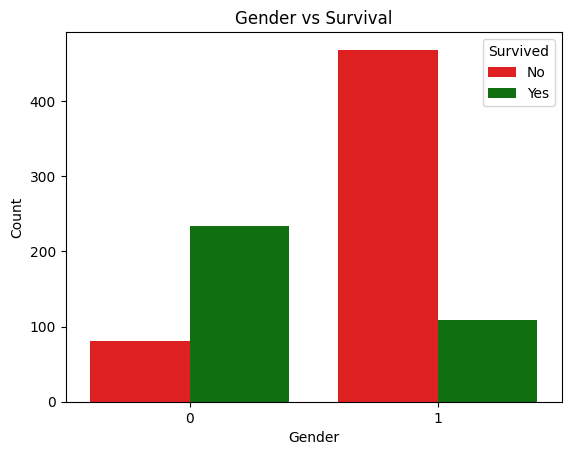

In [278]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=data, palette = ["Red", "Green"])

plt.title("Gender vs Survival")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show() # more males died

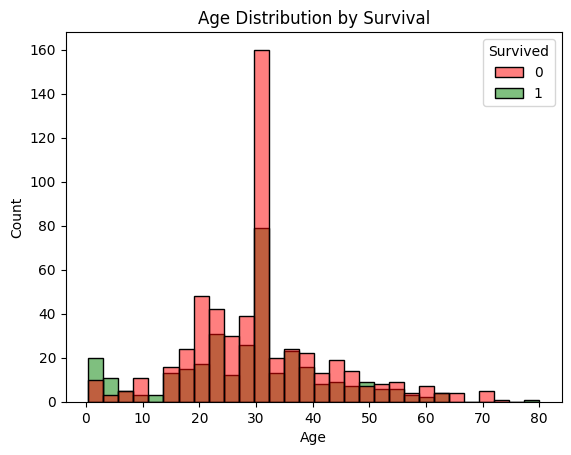

In [279]:
sns.histplot(data, x='Age', hue='Survived', bins=30, kde=False, palette = ["Red", "Green"])

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show() # people around age 30 died more

In [280]:
data[(data["Age"]>=25) & (data["Age"]<=35)]["Survived"].value_counts()

,count
Survived,
0,255
1,141


In [281]:
data[(data["Age"]>=0) & (data["Age"]<=25)]["Survived"].value_counts()

,count
Survived,
0,177
1,124


In [282]:
data[(data["Age"]>=35)]["Survived"].value_counts()

,count
Survived,
0,141
1,94


In [283]:
print(f"{((255/(255+141))*100):.2f}% people within age 25-35 died")
print(f"{((177/(177+124))*100):.2f}% people below age 25 died")
print(f"{((141/(141+94))*100):.2f}% people above age 35 died")

64.39% people within age 25-35 died
58.80% people below age 25 died
60.00% people above age 35 died


## **Train Test Split and Normalization**

In [288]:
train = train.drop(columns = ["Survived"])

In [289]:
from sklearn.model_selection import train_test_split as splitter # time to split original training set into train and val set to evaluate model performance before final submission of actual test set predictions

In [290]:
x_train, x_test, y_train, y_test = splitter(train, y, test_size = 0.25, stratify = y, random_state = 42)

In [291]:
test.shape

(418, 9)

In [ ]:
# we will normalize data using Standard Scaler which uses the formula: x = x-mean/std, to scale down mean to zero and unit variance
# so numerically large values dont imbalance the dataset and the model learns from statistical relations from features

In [292]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
test = scaler.transform(test) # submission test set also transform using same scaler since model will be trained on scaled x_train

## **Training and Evaluating The Model**

In [293]:
from sklearn.linear_model import LogisticRegression

In [294]:
model = LogisticRegression(max_iter = 300, penalty = "l2", verbose = 1, solver = 'lbfgs', random_state = 42)
model.fit(x_train, y_train) # training model

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


LogisticRegression(max_iter=300, random_state=42, verbose=1)

In [295]:
pred = model.predict(x_test) #predicting on val set

In [296]:
from sklearn.metrics import accuracy_score

In [297]:
accuracy_score(y_test, pred) # evaluating validation accuracy: 77.5784%

0.7802690582959642

In [298]:
accuracy_score(y_train, model.predict(x_train))
# evaluating train accuracy: 80.0898%, since train and test accuracies dont have much difference, so the model is neither overfitting nor underfitting

0.811377245508982

In [320]:
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix(y_test, pred)

array([[114,  23],
       [ 26,  60]])

In [317]:
report = classification_report(y_test, pred, output_dict=True)
report = pd.DataFrame(report).transpose()
report.style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
0,0.814286,0.832117,0.823105,137.000000
1,0.722892,0.697674,0.710059,86.000000
accuracy,0.780269,0.780269,0.780269,0.780269
macro avg,0.768589,0.764896,0.766582,223.000000
weighted avg,0.779040,0.780269,0.779509,223.000000


<Axes: >

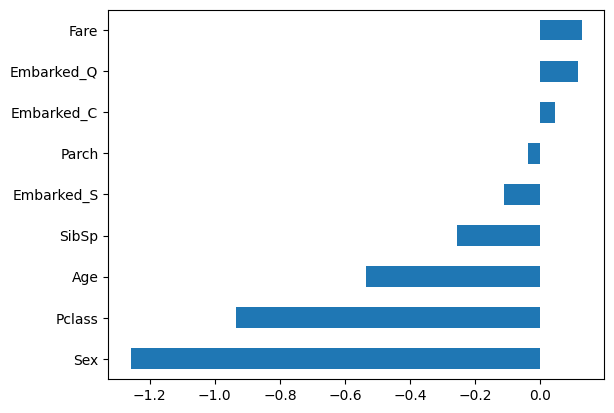

In [300]:
coefficients = pd.Series(model.coef_[0], index=train.columns)
coefficients.sort_values().plot(kind="barh")

In [305]:
coefficients = pd.DataFrame(model.coef_[0], index=train.columns)
coefficients
# shows the weights for each feature found by the model, notice the negative correlation of Sex with Survived?
# The lesser the "Sex" value, higher the chance of survival, means females survive more

,0
Pclass,-0.935957
Sex,-1.258847
Age,-0.534708
SibSp,-0.255462
Parch,-0.037286
Fare,0.127713
Embarked_C,0.044529
Embarked_Q,0.117146
Embarked_S,-0.110729


## **Kaggle Submission**

In [301]:
# time to predict on actual test set and submit then check final accuracy score on kaggle

In [302]:
predictions = model.predict(test)

In [303]:
results = pd.DataFrame({"PassengerId": PID_test, "Survived": predictions})
results

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [304]:
results.to_csv("logistic.csv",header=True,index=False)
from google.colab import files
files.download("logistic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

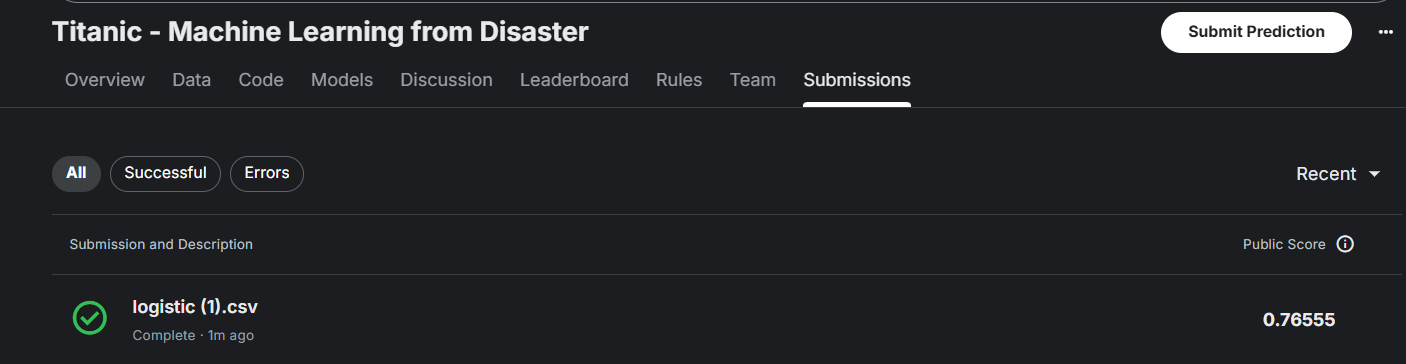